# FlashAttention Latency Benchmarking

Compare latency and throughput across three implementations:
- **SDPA**: PyTorch's scaled_dot_product_attention (official FlashAttention-2 kernels)
- **Naive**: Pure PyTorch implementation (materializes full N×N attention matrix)
- **Flash (Triton)**: Our Triton implementation

Measures across a range of sequence lengths with multiple shapes.

**Note:** All variants use fp32 for fair comparison. Flash kernel may OOM on shared memory for head_dim=128 (marked as "OOM(SharedMem)").

In [86]:
import sys
from pathlib import Path
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

sys.path.insert(0, str(Path().resolve().parent / "src"))
from flash_attention import naive_attention, flash_attention_forward, FlashAttentionTriton

torch.backends.cuda.benchmark = False

print(f"GPU: {torch.cuda.get_device_name()}")
print(f"CUDA: {torch.version.cuda}")
print(f"PyTorch: {torch.__version__}")

GPU: NVIDIA GeForce RTX 4070 Ti
CUDA: 13.0
PyTorch: 2.14.0+cu130


In [87]:
def cuda_time_ms(fn, warmup=25, rep=50):
    """
    Time a CUDA function in milliseconds, measuring single-call latency.
    Synchronizes after each call to measure actual kernel execution time,
    not pipelined/overlapped execution.
    """
    # Warmup
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    
    # Timed runs - synchronize after each call to measure latency per call
    times = []
    for _ in range(rep):
        torch.cuda.synchronize()
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        start.record()
        fn()
        end.record()
        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))
    
    return np.mean(times)

def benchmark_variant(fn, num_runs=3, warmup=10, rep=20):
    """
    Run multiple independent benchmarks and aggregate statistics.
    
    Args:
        fn: Function to benchmark
        num_runs: Number of independent benchmark runs
        warmup: Warmup iterations per run
        rep: Timing iterations per run
    
    Returns:
        dict with mean, std, min, max timings in ms
    """
    times = []
    for _ in range(num_runs):
        t = cuda_time_ms(fn, warmup=warmup, rep=rep)
        times.append(t)
    
    times = np.array(times)
    return {
        'mean': np.mean(times),
        'std': np.std(times),
        'min': np.min(times),
        'max': np.max(times),
    }

print("Timing utilities ready (single-call latency with repeat runs and aggregation)")

Timing utilities ready (single-call latency with repeat runs and aggregation)


In [88]:
SHAPES = [
    (1, 1, 128, 64),
    (1, 4, 256, 64),
    (2, 8, 512, 64),
    (1, 1, 1024, 128),
    (2, 8, 2048, 128),
]

CAUSAL_VALUES = [False, True]
PEAK_GBPS = 1790.0
results = []

print(f"Shape configurations: {len(SHAPES)}")
print(f"Causal modes: {len(CAUSAL_VALUES)}")
print(f"Total benchmarks: {len(SHAPES) * len(CAUSAL_VALUES) * 3}")
print()
print("Starting benchmarks...")

Shape configurations: 5
Causal modes: 2
Total benchmarks: 30

Starting benchmarks...


In [ ]:
hdr = f"{'B':>2} {'H':>2} {'N':>5} {'D':>3} {'causal':>6} {'variant':>7} {'ms (mean±std)':>18} {'GB/s':>8} {'%peak':>6} {'x/sdpa':>8}"
print(hdr)
print("-" * len(hdr))

for causal in CAUSAL_VALUES:
    for batch, heads, seq_len, head_dim in SHAPES:
        # Use fp32 for all variants (fair comparison)
        q_fp32 = torch.randn(batch, heads, seq_len, head_dim, device='cuda', dtype=torch.float32)
        k_fp32 = torch.randn(batch, heads, seq_len, head_dim, device='cuda', dtype=torch.float32)
        v_fp32 = torch.randn(batch, heads, seq_len, head_dim, device='cuda', dtype=torch.float32)
        
        total_elements = batch * heads * seq_len * head_dim
        approx_bytes = 5 * total_elements * 4
        
        variants = {
            "sdpa": lambda: F.scaled_dot_product_attention(q_fp32, k_fp32, v_fp32, is_causal=causal),
            "naive": lambda: naive_attention(q_fp32, k_fp32, v_fp32, is_causal=causal),
            "flash": lambda: FlashAttentionTriton.apply(q_fp32, k_fp32, v_fp32, causal),
        }
        
        times_dict = {}
        for name, fn in variants.items():
            try:
                stats = benchmark_variant(fn, num_runs=3, warmup=10, rep=20)
                times_dict[name] = stats
            except RuntimeError as e:
                error_msg = str(e).lower()
                if "out of memory" in error_msg or "out of resource" in error_msg or "shared memory" in error_msg:
                    times_dict[name] = None
                    if name == "flash":
                        times_dict[name] = "OOM_SharedMem"
                else:
                    print(f"Error in {name}: {e}")
                    times_dict[name] = None
        
        for name, stats in times_dict.items():
            if isinstance(stats, str):  # OOM_SharedMem marker
                causal_str = "yes" if causal else "no"
                print(f"{batch:>2} {heads:>2} {seq_len:>5} {head_dim:>3} {causal_str:>6} {name:>7} {'OOM(SharedMem)':>18} {'---':>8} {'---':>6} {'---':>8}")
            elif stats is not None:
                t_mean = stats['mean']
                t_std = stats['std']
                gbps = approx_bytes / (t_mean * 1e6)
                pct_peak = 100 * gbps / PEAK_GBPS
                speedup = times_dict.get("sdpa", {}).get('mean', 1) / t_mean if isinstance(times_dict.get("sdpa"), dict) else 1.0
                
                result_row = {
                    "batch": batch,
                    "heads": heads,
                    "seq_len": seq_len,
                    "head_dim": head_dim,
                    "causal": causal,
                    "variant": name,
                    "ms": t_mean,
                    "ms_std": t_std,
                    "ms_min": stats['min'],
                    "ms_max": stats['max'],
                    "gbps": gbps,
                    "pct_peak": pct_peak,
                    "speedup_vs_sdpa": speedup,
                }
                results.append(result_row)
                
                causal_str = "yes" if causal else "no"
                timing_str = f"{t_mean:.3f}±{t_std:.3f}"
                print(f"{batch:>2} {heads:>2} {seq_len:>5} {head_dim:>3} {causal_str:>6} {name:>7} {timing_str:>18} {gbps:>8.1f} {pct_peak:>6.1f} {speedup:>8.2f}")
            else:
                causal_str = "yes" if causal else "no"
                print(f"{batch:>2} {heads:>2} {seq_len:>5} {head_dim:>3} {causal_str:>6} {name:>7} {'OOM':>18} {'---':>8} {'---':>6} {'---':>8}")

print("\nBenchmarking complete!")

In [90]:
df = pd.DataFrame(results)
print(f"Total successful runs: {len(df)}")
print()
print(df.head(15))

Total successful runs: 30

    batch  heads  seq_len  head_dim  causal variant        ms    ms_std  \
0       1      1      128        64   False    sdpa  0.200930  0.002254   
1       1      1      128        64   False   naive  0.544418  0.001848   
2       1      1      128        64   False   flash  0.362764  0.008363   
3       1      4      256        64   False    sdpa  0.199034  0.003976   
4       1      4      256        64   False   naive  0.527887  0.004171   
5       1      4      256        64   False   flash  0.362934  0.001418   
6       2      8      512        64   False    sdpa  0.278217  0.001544   
7       2      8      512        64   False   naive  0.550551  0.031340   
8       2      8      512        64   False   flash  0.347588  0.007722   
9       1      1     1024       128   False    sdpa  0.299796  0.001512   
10      1      1     1024       128   False   naive  0.542883  0.002382   
11      1      1     1024       128   False   flash  0.352145  0.006155  

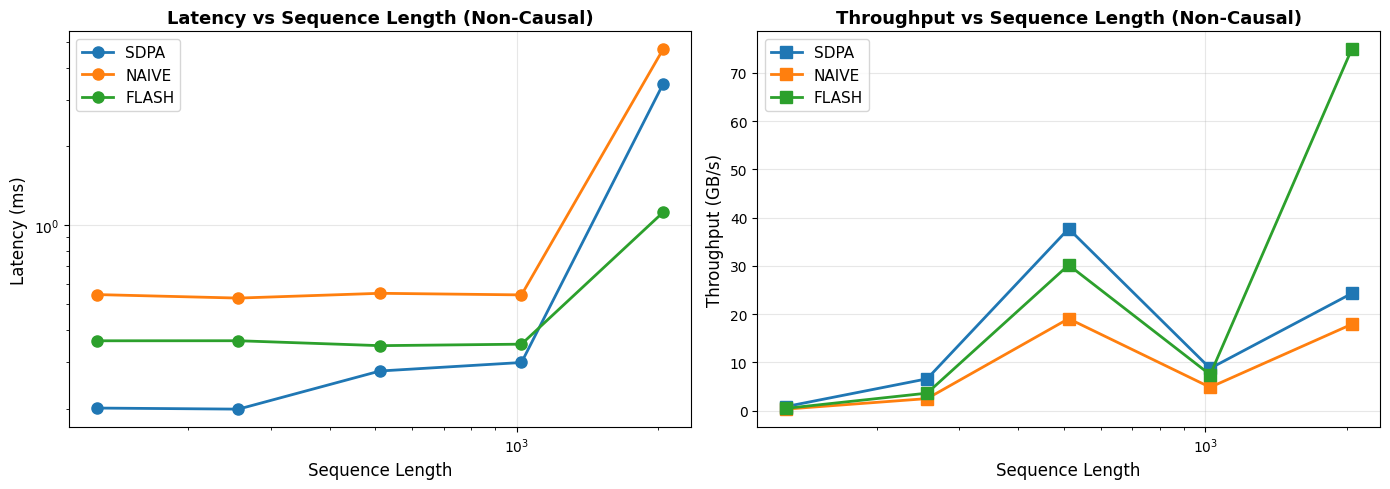

In [91]:
df_noncausal = df[df['causal'] == False]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for variant in ['sdpa', 'naive', 'flash']:
    variant_data = df_noncausal[df_noncausal['variant'] == variant]
    variant_data = variant_data.sort_values('seq_len')
    axes[0].plot(variant_data['seq_len'], variant_data['ms'], 'o-', linewidth=2, markersize=8, label=variant.upper())

axes[0].set_xlabel('Sequence Length', fontsize=12)
axes[0].set_ylabel('Latency (ms)', fontsize=12)
axes[0].set_title('Latency vs Sequence Length (Non-Causal)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')
axes[0].set_yscale('log')

for variant in ['sdpa', 'naive', 'flash']:
    variant_data = df_noncausal[df_noncausal['variant'] == variant]
    variant_data = variant_data.sort_values('seq_len')
    axes[1].plot(variant_data['seq_len'], variant_data['gbps'], 's-', linewidth=2, markersize=8, label=variant.upper())

axes[1].set_xlabel('Sequence Length', fontsize=12)
axes[1].set_ylabel('Throughput (GB/s)', fontsize=12)
axes[1].set_title('Throughput vs Sequence Length (Non-Causal)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

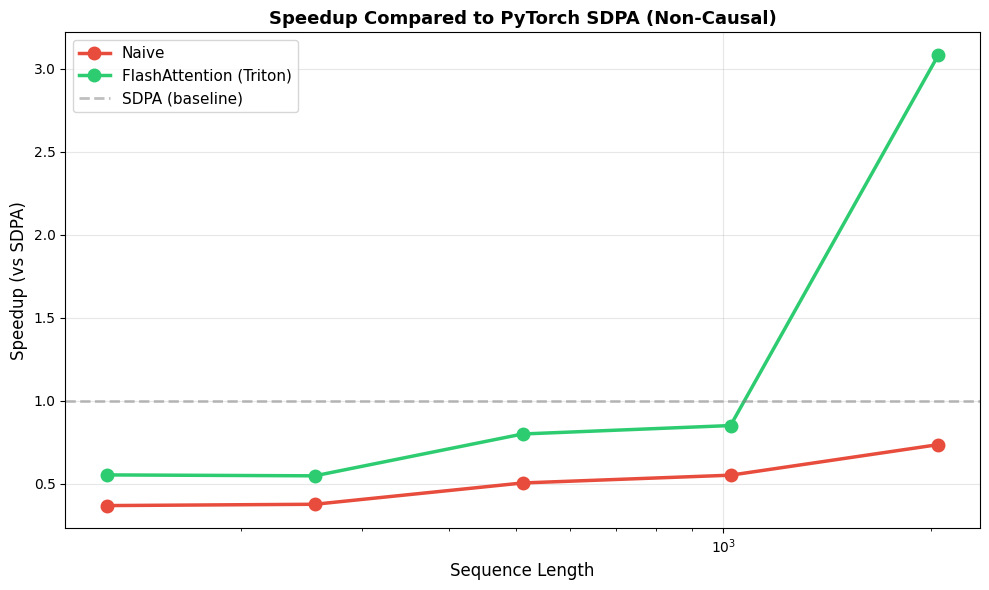

In [92]:
fig, ax = plt.subplots(figsize=(10, 6))

for variant in ['naive', 'flash']:
    variant_data = df_noncausal[df_noncausal['variant'] == variant]
    variant_data = variant_data.sort_values('seq_len')
    label = 'Naive' if variant == 'naive' else 'FlashAttention (Triton)'
    color = '#e74c3c' if variant == 'naive' else '#2ecc71'
    ax.plot(variant_data['seq_len'], variant_data['speedup_vs_sdpa'], 'o-', linewidth=2.5, 
            markersize=9, label=label, color=color)

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=2, label='SDPA (baseline)')
ax.set_xlabel('Sequence Length', fontsize=12)
ax.set_ylabel('Speedup (vs SDPA)', fontsize=12)
ax.set_title('Speedup Compared to PyTorch SDPA (Non-Causal)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

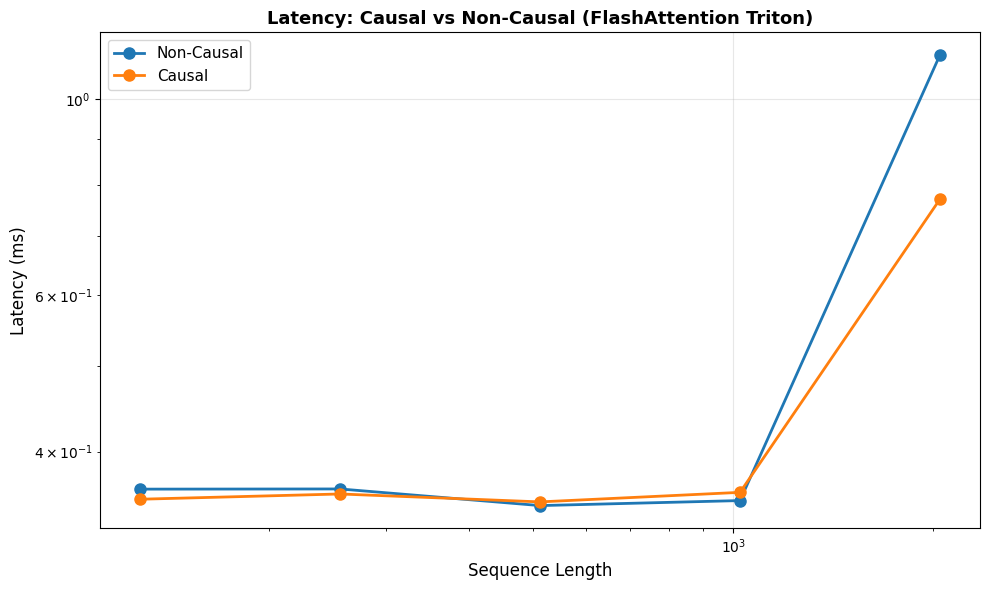

In [93]:
df_flash = df[df['variant'] == 'flash']
fig, ax = plt.subplots(figsize=(10, 6))

for causal in [False, True]:
    causal_data = df_flash[df_flash['causal'] == causal]
    causal_data = causal_data.sort_values('seq_len')
    label = 'Causal' if causal else 'Non-Causal'
    ax.plot(causal_data['seq_len'], causal_data['ms'], 'o-', linewidth=2, markersize=8, label=label)

ax.set_xlabel('Sequence Length', fontsize=12)
ax.set_ylabel('Latency (ms)', fontsize=12)
ax.set_title('Latency: Causal vs Non-Causal (FlashAttention Triton)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

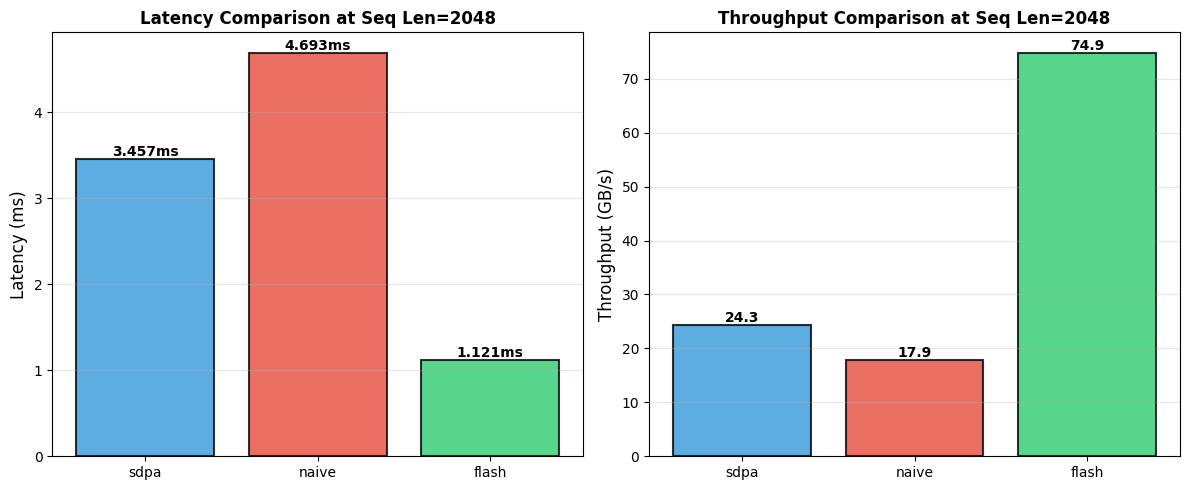

In [94]:
max_seq_len = df_noncausal['seq_len'].max()
df_max_seq = df_noncausal[df_noncausal['seq_len'] == max_seq_len]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

variants = df_max_seq['variant'].values
latencies = df_max_seq['ms'].values
colors = ['#3498db', '#e74c3c', '#2ecc71']

bars1 = ax1.bar(variants, latencies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Latency (ms)', fontsize=12)
ax1.set_title(f'Latency Comparison at Seq Len={max_seq_len}', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars1, latencies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.3f}ms', 
             ha='center', va='bottom', fontweight='bold')

throughputs = df_max_seq['gbps'].values
bars2 = ax2.bar(variants, throughputs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Throughput (GB/s)', fontsize=12)
ax2.set_title(f'Throughput Comparison at Seq Len={max_seq_len}', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars2, throughputs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.1f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [95]:
print("\n" + "="*70)
print("PERFORMANCE SUMMARY")
print("="*70)

print("\n1. LATENCY (lower is better)")
print("-" * 50)
for variant in ['sdpa', 'naive', 'flash']:
    variant_data = df_noncausal[df_noncausal['variant'] == variant]
    if len(variant_data) > 0:
        min_ms = variant_data['ms'].min()
        max_ms = variant_data['ms'].max()
        mean_ms = variant_data['ms'].mean()
        print(f"{variant.upper():10} | min: {min_ms:7.4f}ms | max: {max_ms:7.4f}ms | mean: {mean_ms:7.4f}ms")

print("\n2. THROUGHPUT (higher is better)")
print("-" * 50)
for variant in ['sdpa', 'naive', 'flash']:
    variant_data = df_noncausal[df_noncausal['variant'] == variant]
    if len(variant_data) > 0:
        mean_gbps = variant_data['gbps'].mean()
        max_gbps = variant_data['gbps'].max()
        pct_peak = variant_data['pct_peak'].mean()
        print(f"{variant.upper():10} | mean: {mean_gbps:7.1f} GB/s | max: {max_gbps:7.1f} GB/s | {pct_peak:.1f}% peak")

print("\n3. SPEEDUP VS SDPA (higher is better)")
print("-" * 50)
for variant in ['naive', 'flash']:
    variant_data = df_noncausal[df_noncausal['variant'] == variant]
    if len(variant_data) > 0:
        mean_speedup = variant_data['speedup_vs_sdpa'].mean()
        min_speedup = variant_data['speedup_vs_sdpa'].min()
        max_speedup = variant_data['speedup_vs_sdpa'].max()
        print(f"{variant.upper():10} | mean: {mean_speedup:.2f}x | min: {min_speedup:.2f}x | max: {max_speedup:.2f}x")

print("\n" + "="*70)


PERFORMANCE SUMMARY

1. LATENCY (lower is better)
--------------------------------------------------
SDPA       | min:  0.1990ms | max:  3.4567ms | mean:  0.8869ms
NAIVE      | min:  0.5279ms | max:  4.6932ms | mean:  1.3718ms
FLASH      | min:  0.3476ms | max:  1.1207ms | mean:  0.5092ms

2. THROUGHPUT (higher is better)
--------------------------------------------------
SDPA       | mean:    15.6 GB/s | max:    37.7 GB/s | 0.9% peak
NAIVE      | mean:     8.9 GB/s | max:    19.0 GB/s | 0.5% peak
FLASH      | mean:    23.3 GB/s | max:    74.9 GB/s | 1.3% peak

3. SPEEDUP VS SDPA (higher is better)
--------------------------------------------------
NAIVE      | mean: 0.51x | min: 0.37x | max: 0.74x
FLASH      | mean: 1.17x | min: 0.55x | max: 3.08x



In [96]:
print("\nDETAILED RESULTS (Non-Causal)")
print("=" * 100)
display_df = df_noncausal[['batch', 'heads', 'seq_len', 'head_dim', 'variant', 'ms', 'gbps', 'pct_peak', 'speedup_vs_sdpa']].copy()
display_df = display_df.sort_values(['seq_len', 'variant'])
display_df['ms'] = display_df['ms'].round(4)
display_df['gbps'] = display_df['gbps'].round(1)
display_df['pct_peak'] = display_df['pct_peak'].round(1)
display_df['speedup_vs_sdpa'] = display_df['speedup_vs_sdpa'].round(2)
print(display_df.to_string(index=False))


DETAILED RESULTS (Non-Causal)
 batch  heads  seq_len  head_dim variant     ms  gbps  pct_peak  speedup_vs_sdpa
     1      1      128        64   flash 0.3628   0.5       0.0             0.55
     1      1      128        64   naive 0.5444   0.3       0.0             0.37
     1      1      128        64    sdpa 0.2009   0.8       0.0             1.00
     1      4      256        64   flash 0.3629   3.6       0.2             0.55
     1      4      256        64   naive 0.5279   2.5       0.1             0.38
     1      4      256        64    sdpa 0.1990   6.6       0.4             1.00
     2      8      512        64   flash 0.3476  30.2       1.7             0.80
     2      8      512        64   naive 0.5506  19.0       1.1             0.51
     2      8      512        64    sdpa 0.2782  37.7       2.1             1.00
     1      1     1024       128   flash 0.3521   7.4       0.4             0.85
     1      1     1024       128   naive 0.5429   4.8       0.3             0.

In [97]:
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

df_flash_noncausal = df_noncausal[df_noncausal['variant'] == 'flash']
df_sdpa_noncausal = df_noncausal[df_noncausal['variant'] == 'sdpa']

if len(df_flash_noncausal) > 0 and len(df_sdpa_noncausal) > 0:
    flash_mean_speedup = (df_sdpa_noncausal['ms'].mean() / df_flash_noncausal['ms'].mean())
    print(f"\nFlashAttention (Triton) averages {flash_mean_speedup:.2f}x SDPA speed")
    print(f"(Note: PyTorch SDPA uses highly optimized hand-tuned CUTLASS kernels)")
    
if len(df_noncausal[df_noncausal['variant'] == 'naive']) > 0:
    naive_mean_speedup = df_noncausal[df_noncausal['variant'] == 'naive']['speedup_vs_sdpa'].mean()
    print(f"\nNaive attention is {naive_mean_speedup:.2f}x slower than SDPA")
    print(f"(Materializes full N×N attention matrix)")

flash_throughput = df_flash_noncausal['gbps'].mean()
pct_peak = df_flash_noncausal['pct_peak'].mean()
print(f"\nFlashAttention achieves {flash_throughput:.1f} GB/s ({pct_peak:.1f}% of peak GPU bandwidth)")

print("\n" + "="*70)


KEY FINDINGS

FlashAttention (Triton) averages 1.74x SDPA speed
(Note: PyTorch SDPA uses highly optimized hand-tuned CUTLASS kernels)

Naive attention is 0.51x slower than SDPA
(Materializes full N×N attention matrix)

FlashAttention achieves 23.3 GB/s (1.3% of peak GPU bandwidth)

